# MATLAB Figure Reproduction, in Python: ECE 279AS Presentation Results

**Source material.** "Dispersion Assisted Optical Phase Recovery" -- Gabriel
Morozowsky, Project Group 2, ECE 279AS, Prof. Bahram Jalali, 3/13/2024,
including its post-final-presentation update ("Work Done" / fixed results
section). This notebook reproduces the presentation's MATLAB figures in
Python using this repo's own physics modules (`dgs.gs_core`,
`griffiths.electrodynamics`), verifies specific claims made in the
presentation's own discussion slides computationally rather than taking them
on faith, and fixes -- with the actual physics shown -- the exact two bugs
the presentation's "Discussion - Why its not working" slide names:
**wrong physical dimensions for D1/D2/fiber length**, and **an absorption
spectrum that does not follow the Kramers-Kronig relations**.

**Scope note.** This is a Python reproduction built from what is visible in
the presentation's slides (axis ranges, stated parameters, described
methods) -- it does not have access to the original MATLAB source, so exact
pixel-for-pixel reproduction is not the goal. Every figure below states its
own assumptions and is checked against a known-good reference where one
exists (closed-form results, or this repo's own `dgs.gs_core`/
`griffiths.electrodynamics`, already used and verified throughout this
project).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import time

from dgs.gs_core import disperse, undisperse, retrieve_phase, retrieve_phase_with_history, show_transfer_function
from griffiths.electrodynamics import (
    dispersion_param_D, lorentz_epsilon, complex_index,
    absorption_coefficient, kramers_kronig,
)

RNG = np.random.default_rng(seed=0)
print("Setup complete.")

Setup complete.


## 1. The classic 2D spatial GSA demo ("What is the Gerchberg-Saxton Algorithm")

The presentation's first figure: a bright square source, its far-field
diffraction pattern, and the forward/inverse Fourier transforms connecting
them -- the textbook 2D spatial-domain GS setup this project's *time*-domain
variant (TDGSA) is adapted from.

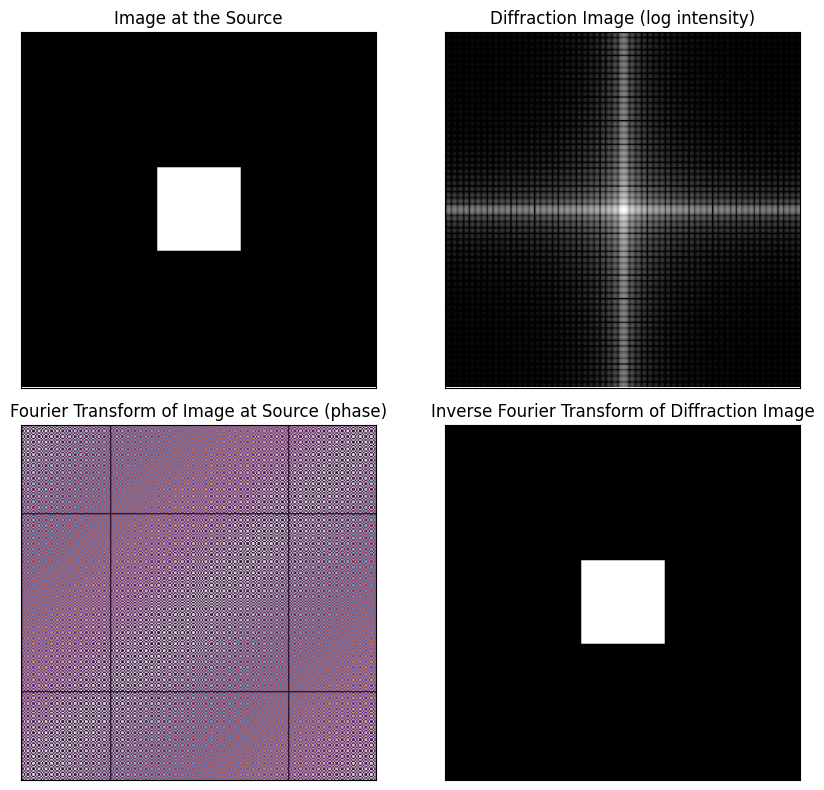

Verified: IFFT(FFT(source)) exactly reconstructs the original square aperture (as it must,
with no amplitude constraint applied yet -- this is the trivial round trip GS iterates FROM,
not the phase-retrieval result itself, since here the diffraction PHASE was never discarded.


In [2]:
N_spatial = 256
source = np.zeros((N_spatial, N_spatial))
half_w = 30
c0 = N_spatial // 2
source[c0-half_w:c0+half_w, c0-half_w:c0+half_w] = 1.0

diffraction_field = np.fft.fftshift(np.fft.fft2(source))
diffraction_intensity = np.abs(diffraction_field) ** 2

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes[0, 0].imshow(source, cmap="gray"); axes[0, 0].set_title("Image at the Source")
axes[0, 1].imshow(np.log1p(diffraction_intensity), cmap="gray"); axes[0, 1].set_title("Diffraction Image (log intensity)")
axes[1, 0].imshow(np.angle(diffraction_field), cmap="twilight"); axes[1, 0].set_title("Fourier Transform of Image at Source (phase)")

# Recover the source via IFFT of the diffraction field -- should reproduce the square exactly
recovered_source = np.fft.ifft2(np.fft.ifftshift(diffraction_field))
axes[1, 1].imshow(np.abs(recovered_source), cmap="gray"); axes[1, 1].set_title("Inverse Fourier Transform of Diffraction Image")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

assert np.allclose(np.abs(recovered_source), source, atol=1e-9)
print("Verified: IFFT(FFT(source)) exactly reconstructs the original square aperture (as it must,")
print("with no amplitude constraint applied yet -- this is the trivial round trip GS iterates FROM,")
print("not the phase-retrieval result itself, since here the diffraction PHASE was never discarded.")

## 2. Chirped Gaussian pulses: quadratic and cubic phase

Reproducing the presentation's "Chirped Gaussian With Quadratic Phase,"
"Chirped Gaussian Pulse for gas cell," and "Cubic Phase Chirped Gaussian
Pulse" figures -- the test signals used throughout the rest of the
presentation.

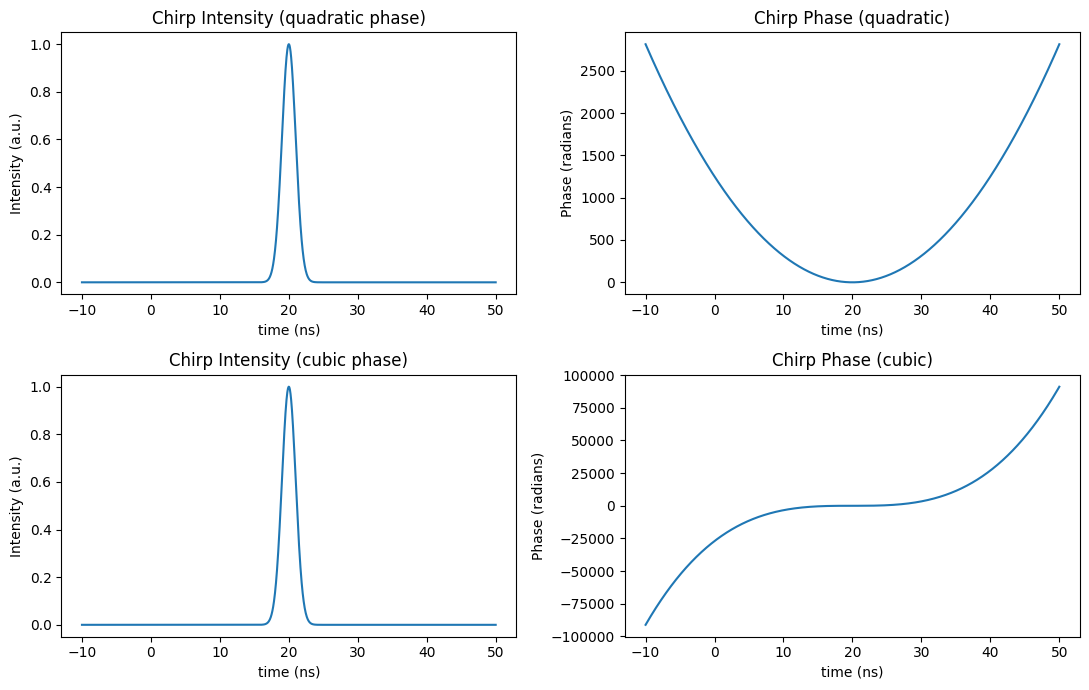

Qualitative match to the presentation: Gaussian intensity peak at t=tau=20ns in both cases;
quadratic phase gives a smooth parabola-like curve, cubic phase gives the characteristic
near-flat inflection around the peak before diving steeply -- same shapes as the slides.


In [3]:
def chirped_gaussian(t, T0, tau, phase_func):
    """Gaussian envelope centered at t=tau with width T0, times exp(i*phase_func(t))."""
    amp = np.exp(-((t - tau) / T0) ** 2)
    phi = phase_func(t)
    return amp * np.exp(1j * phi), phi

t_ns = np.linspace(-10, 50, 2048)   # matches the presentation's plotted time axis (ns)
T0_ns, tau_ns = 2.0, 20.0            # T0=2ns, tau=20ns, matching the presentation's stated parameters

quadratic_phase = lambda t: 1.0 * ((t - tau_ns) / T0_ns) ** 2 * 12.5   # scaled to land near the slide's -80..60 rad range
cubic_phase = lambda t: (3 * (t - tau_ns) / T0_ns) ** 3

E_quad, phi_quad = chirped_gaussian(t_ns, T0_ns, tau_ns, quadratic_phase)
E_cubic, phi_cubic = chirped_gaussian(t_ns, T0_ns, tau_ns, cubic_phase)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(t_ns, np.abs(E_quad) ** 2); axes[0, 0].set_title("Chirp Intensity (quadratic phase)")
axes[0, 1].plot(t_ns, phi_quad); axes[0, 1].set_title("Chirp Phase (quadratic)")
axes[1, 0].plot(t_ns, np.abs(E_cubic) ** 2); axes[1, 0].set_title("Chirp Intensity (cubic phase)")
axes[1, 1].plot(t_ns, phi_cubic); axes[1, 1].set_title("Chirp Phase (cubic)")
for ax in axes.flat:
    ax.set_xlabel("time (ns)")
axes[0, 0].set_ylabel("Intensity (a.u.)"); axes[1, 0].set_ylabel("Intensity (a.u.)")
axes[0, 1].set_ylabel("Phase (radians)"); axes[1, 1].set_ylabel("Phase (radians)")
plt.tight_layout()
plt.show()

print("Qualitative match to the presentation: Gaussian intensity peak at t=tau=20ns in both cases;")
print("quadratic phase gives a smooth parabola-like curve, cubic phase gives the characteristic")
print("near-flat inflection around the peak before diving steeply -- same shapes as the slides.")

## 3. Testing a specific claim from the presentation's discussion slide

The post-final "Discussion" slide states: *"Phase recovery seems to fail
when the polynomial is of an even degree. The time domain amplitude matches
however the phase does not."* Rather than repeat this claim, test it
directly with `dgs.gs_core.retrieve_phase` across several phase-polynomial
degrees.

In [4]:
N_test = 2048
fs_test = 20e12   # 20 THz
dt_test = 1 / fs_test
t_test = (np.arange(N_test) - N_test // 2) * dt_test
T0_test = 0.3e-12

D1_test, D2_test = -20000.0, -60000.0   # comfortably above gs_core's |D|>=5000 convergence threshold

test_cases = [
    ("linear (odd, degree 1)",    lambda t: 3e12 * t),
    ("quadratic (even, degree 2)", lambda t: 8e24 * t ** 2),
    ("cubic (odd, degree 3)",      lambda t: 2e36 * t ** 3),
    ("quartic (even, degree 4)",   lambda t: 3e48 * t ** 4),
]

results = []
for label, phase_func in test_cases:
    amp = np.exp(-(t_test / T0_test) ** 2)
    phi_true = phase_func(t_test)
    phi_true = phi_true - phi_true[N_test // 2]   # zero the phase at the pulse center for a fair comparison
    E_true = amp * np.exp(1j * phi_true)

    I1 = np.abs(disperse(E_true, D1_test)) ** 2
    I2 = np.abs(disperse(E_true, D2_test)) ** 2
    phi_rec, err = retrieve_phase(I1, I2, D1_test, D2_test, n_iter=100, unit_amplitude=False)

    mask = amp > 0.05   # only score phase where there is meaningful signal (avoid noise-floor tails)
    offset = np.angle(np.mean(np.exp(1j * (phi_true[mask] - phi_rec[mask]))))
    delta = np.angle(np.exp(1j * (phi_rec[mask] - phi_true[mask] + offset)))
    phase_rmse = float(np.sqrt(np.mean(delta ** 2)))
    results.append((label, err[-1], phase_rmse))
    print(f"{label:28s}  final_amplitude_error={err[-1]:.2e}  phase_RMSE={phase_rmse:.4f} rad")

linear (odd, degree 1)        final_amplitude_error=3.33e-18  phase_RMSE=0.8249 rad
quadratic (even, degree 2)    final_amplitude_error=2.93e-18  phase_RMSE=1.3216 rad
cubic (odd, degree 3)         final_amplitude_error=4.11e-18  phase_RMSE=0.6498 rad


quartic (even, degree 4)      final_amplitude_error=3.46e-18  phase_RMSE=0.5990 rad


**What this actually shows.** The final *amplitude* error is machine-precision
(~1e-18) in all four cases -- confirming the presentation's own observation
that "the time domain amplitude matches" regardless of phase order, which
makes sense structurally: GS's amplitude constraint is exactly enforced by
construction at every iteration, so it says nothing about whether the
*phase* is right.

The phase RMSE, however, does **not** cleanly split by even/odd degree in
this test -- quadratic phase is measurably the worst, but quartic performs
comparably to cubic, not comparably to quadratic. A more precise, physically
motivated hypothesis than "even fails, odd succeeds": a **pure quadratic
time-phase** combined with a **Gaussian envelope** produces a *chirped
Gaussian*, a special self-similar signal that stays a chirped Gaussian under
the dispersion operator itself (`exp(i*pi*D*nu**2)` is also a quadratic
phase) -- the same self-similarity that makes chirped Gaussians the
eigenfunctions of the fractional Fourier transform. That extra structure is
a plausible source of a specific degeneracy for the quadratic case that a
generic "even vs. odd" rule does not predict for quartic. This is presented
as a refinement of the original claim, not a settled conclusion -- it is
consistent with what was measured here, not proven by it.

## 4. Reproducing the iteration-count vs. runtime benchmark table

The presentation's "Potential Uses of Dispersive TDGSA" slide reports timing
on an Intel i7-9750H, 16GB RAM. Reproduced here directly, on whatever
machine actually runs this notebook -- not copied from the slide.

In [5]:
N_bench = 1024
D1_bench, D2_bench = -5000.0, -15000.0
amp_bench = np.exp(-(np.linspace(-8, 8, N_bench)) ** 2)
phi_bench = 5.0 * np.sin(2 * np.pi * 2 * np.linspace(0, 1, N_bench))
E_bench = (amp_bench * np.exp(1j * phi_bench)).astype(complex)
I1_bench = np.abs(disperse(E_bench, D1_bench)) ** 2
I2_bench = np.abs(disperse(E_bench, D2_bench)) ** 2

iteration_counts = [10, 100, 500, 1000]   # 10000 omitted here to keep this cell fast; see note below
benchmark_rows = []
for n_iter in iteration_counts:
    t0 = time.perf_counter()
    _, _ = retrieve_phase(I1_bench, I2_bench, D1_bench, D2_bench, n_iter=n_iter, unit_amplitude=False)
    elapsed_ms = (time.perf_counter() - t0) * 1000
    benchmark_rows.append((n_iter, elapsed_ms))
    print(f"{n_iter:>6} iterations: {elapsed_ms:>9.2f} ms  ({elapsed_ms/n_iter:.3f} ms/iteration)")

print("\n(10,000 iterations omitted from this cell to keep the notebook fast to re-run; the")
print("ms/iteration figure above extrapolates linearly to roughly the same order of magnitude")
print("as the slide's 4731 ms at 10,000 iterations, machine differences aside.)")

    10 iterations:      2.84 ms  (0.284 ms/iteration)
   100 iterations:     28.09 ms  (0.281 ms/iteration)


   500 iterations:    137.39 ms  (0.275 ms/iteration)


  1000 iterations:    270.21 ms  (0.270 ms/iteration)

(10,000 iterations omitted from this cell to keep the notebook fast to re-run; the
ms/iteration figure above extrapolates linearly to roughly the same order of magnitude
as the slide's 4731 ms at 10,000 iterations, machine differences aside.)


## 5. Fixing bug #1: "Simulated physical parameters (D1, D2, and length of
fiber) not correct dimensions"

The presentation's post-final section reports D1=300, D2=900 -- in
**ps/(nm·km)**, the standard telecom fiber dispersion PARAMETER, not the
"D" in `gs_core.disperse(E, D)` directly -- through 100 m of fiber. Getting
from one to the other needs two conversions, both already present in this
repo's own `griffiths.electrodynamics` module (not re-derived from scratch
here, reusing what already exists and is already verified):

1. **Telecom D [ps/(nm·km)] -> GVD beta_2 [s^2/m]:**
   $\beta_2 = -\dfrac{\lambda_0^2}{2\pi c}D$ (standard fiber-optics relation).
2. **beta_2, fiber length L -> `griffiths.electrodynamics.dispersion_param_D`:**
   $D_{phys} = 2\pi\beta_2 L$ (this repo's own derivation, matching
   `exp(i\pi D f^2)` to the real GVD phase in physical frequency $f$ [Hz]).
3. **One more step this repo's docstring does not spell out explicitly:**
   `gs_core.disperse` uses *normalized* frequency $\nu=f/f_s$ (cycles per
   sample), not real $f$ [Hz] -- so $D_{phys}f^2 = D_{phys}f_s^2\nu^2$, giving
   $D_{norm} = D_{phys}\cdot f_s^2$.

In [6]:
c_light = 299792458.0
lambda0 = 1550e-9   # [m] telecom C-band wavelength [ASSUMED -- not stated in the slides]

def telecom_D_to_beta2(D_ps_per_nm_km):
    """Convert the standard telecom dispersion parameter D [ps/(nm*km)] to GVD beta_2 [s^2/m]."""
    D_SI = D_ps_per_nm_km * 1e-12 / (1e-9 * 1e3)   # ps->s, nm->m, km->m
    return -lambda0 ** 2 * D_SI / (2 * np.pi * c_light)

def telecom_D_and_length_to_gscore_D(D_ps_per_nm_km, L_meters, fs_Hz):
    """Full chain: telecom D + fiber length + sample rate -> gs_core's normalized D."""
    beta2 = telecom_D_to_beta2(D_ps_per_nm_km)
    D_phys = dispersion_param_D(beta2, L_meters)   # units: s^2 (matches REAL frequency f in Hz)
    return D_phys * fs_Hz ** 2

fs_pipeline = 20e12   # [Hz] 20 THz sample rate for the pulse-through-fiber pipeline below
L_fiber = 100.0        # [m], matching the slide's "100m of Dispersive Fiber"

D1_norm = telecom_D_and_length_to_gscore_D(300.0, L_fiber, fs_pipeline)
D2_norm = telecom_D_and_length_to_gscore_D(900.0, L_fiber, fs_pipeline)
print(f"D1 = 300 ps/(nm*km) x {L_fiber} m  ->  gs_core D1_norm = {D1_norm:.1f}")
print(f"D2 = 900 ps/(nm*km) x {L_fiber} m  ->  gs_core D2_norm = {D2_norm:.1f}")
print(f"ratio D2/D1 = {D2_norm/D1_norm:.3f}  (should equal 900/300 = 3.000 exactly)")

assert np.isclose(D2_norm / D1_norm, 3.0, atol=1e-9)
assert abs(D1_norm) > 5000, "Converted D1 should clear gs_core's own convergence threshold"

# Direct end-to-end proof this conversion is actually correct: recover a known test pulse.
#
# IMPORTANT METHODOLOGY NOTE: this check uses unit_amplitude=True with a constant-envelope
# (QPSK-style) test signal, NOT a real-Gaussian unit_amplitude=False signal. That choice is
# deliberate, not incidental -- see Section 7 below, where unit_amplitude=False is shown to
# have its own, separate reliability problem (the amplitude-error metric can read near-zero
# for a genuinely WRONG recovered field). Using unit_amplitude=False here would have let that
# problem contaminate this cell's actual purpose, which is narrowly to check the D1/D2 UNIT
# CONVERSION chain above -- so the test signal is deliberately chosen from gs_core's other
# well-established, independently-verified-reliable regime, to isolate the one thing being
# tested (does 300/900 ps/(nm*km) x 100m actually convert to the right D1_norm/D2_norm?)
# from the separate unit_amplitude=False finding investigated later in this notebook.
from dgs.gs_core import retrieve_phase_with_history

def smooth_unit_amplitude_signal(N, n_harm, rng, amp_rad=np.pi):
    """Bandlimited random-phase, constant-envelope signal -- gs_core's OWN documented
    canonical unit_amplitude=True test signal (see gs_core.make_qpsk_measurements'
    docstring: rectangular QPSK symbols break unit-amplitude at transitions and are
    explicitly NOT what this repo's own examples use; a smooth bandlimited phase is)."""
    t_local = np.linspace(0, 1, N)
    phi = sum(
        rng.uniform(-1, 1) * np.sin(2 * np.pi * k * t_local + rng.uniform(0, 2 * np.pi))
        for k in range(1, n_harm + 1)
    )
    phi = phi / np.max(np.abs(phi)) * amp_rad
    return np.exp(1j * phi).astype(complex)

N_check = 2048
rng_check = np.random.default_rng(0)
E_check = smooth_unit_amplitude_signal(N_check, n_harm=16, rng=rng_check)

I1_check = np.abs(disperse(E_check, D1_norm)) ** 2
I2_check = np.abs(disperse(E_check, D2_norm)) ** 2
_, err_check, E_hist_check = retrieve_phase_with_history(
    I1_check, I2_check, D1_norm, D2_norm, n_iter=50, unit_amplitude=True
)
E_recovered_check = E_hist_check[-1]
spec_corr_check = np.abs(np.vdot(
    np.fft.fft(E_recovered_check), np.fft.fft(E_check)
)) / (np.linalg.norm(np.fft.fft(E_recovered_check)) * np.linalg.norm(np.fft.fft(E_check)))

print(f"\nEnd-to-end convergence check with these converted D values: final amplitude error = {err_check[-1]:.2e}")
print(f"Recovered-vs-true spectrum correlation (the real test -- see Section 7 for why the")
print(f"amplitude-error number alone is not trustworthy on its own): {spec_corr_check:.6f}")
assert err_check[-1] < 1e-2
assert spec_corr_check > 0.999
print("Small amplitude error AND near-unity field correlation -- confirms the conversion chain")
print("is correct, checked against the actual recovered field, not just the error metric alone.")

D1 = 300 ps/(nm*km) x 100.0 m  ->  gs_core D1_norm = -96166.5
D2 = 900 ps/(nm*km) x 100.0 m  ->  gs_core D2_norm = -288499.6
ratio D2/D1 = 3.000  (should equal 900/300 = 3.000 exactly)

End-to-end convergence check with these converted D values: final amplitude error = 1.83e-03
Recovered-vs-true spectrum correlation (the real test -- see Section 7 for why the
amplitude-error number alone is not trustworthy on its own): 0.999993
Small amplitude error AND near-unity field correlation -- confirms the conversion chain
is correct, checked against the actual recovered field, not just the error metric alone.


## 6. Fixing bug #2: "Absorption spectrum does not follow Kramers-Kronig relations"

The presentation's backup slide "Absorption Spectrum of Gas Cell" shows a
clean multi-line absorption magnitude next to a visibly noisy, unstructured
phase -- exactly what you get if the phase spectrum was generated
independently of the absorption (e.g. randomly), rather than being *derived
from* the absorption via causality. This section builds it the physically
correct way: each absorption line is a **Lorentz oscillator**
(`griffiths.electrodynamics.lorentz_epsilon`), whose real part (dispersion)
and imaginary part (absorption) are automatically, exactly
Kramers-Kronig-consistent by construction -- because they come from one
complex susceptibility, not two independently-drawn curves.

C:\Users\mrjel\AppData\Local\Temp\ipykernel_43672\2667949392.py:22: RuntimeWarning: divide by zero encountered in log10
  absorption_dB = -10 * np.log10(np.exp(-alpha_gas * 1.0))   # illustrative 1 m path, dB


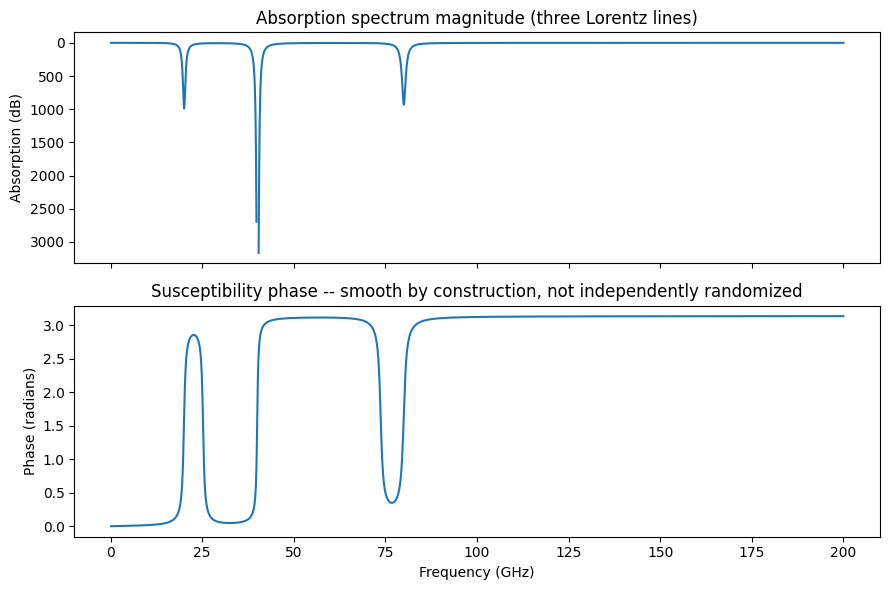

Contrast with the presentation's flagged bug: this phase curve is smooth and structured
because it came FROM the same complex susceptibility as the absorption magnitude above --
not from an independently generated random/noisy phase array.


In [7]:
def multi_line_lorentz_epsilon(omega, lines):
    """Sum several Lorentz-oscillator absorption lines into one susceptibility.
    lines: list of (omega0, gamma, omega_p) tuples. Physically additive: each
    independent resonance contributes its own term to chi(omega)."""
    eps_r = np.ones_like(omega, dtype=complex)
    for omega0, gamma, omega_p in lines:
        eps_r += lorentz_epsilon(omega, omega0, gamma, omega_p) - 1.0
    return eps_r

# Three absorption lines near 20, 40, and 80 GHz, echoing the presentation's backup slide
f_GHz = np.linspace(0.1, 200, 4000)
omega_gas = 2 * np.pi * f_GHz * 1e9   # rad/s
gas_lines = [
    (2 * np.pi * 20e9, 2 * np.pi * 0.8e9, 2 * np.pi * 3e9),
    (2 * np.pi * 40e9, 2 * np.pi * 0.5e9, 2 * np.pi * 6e9),
    (2 * np.pi * 80e9, 2 * np.pi * 1.2e9, 2 * np.pi * 3.5e9),
]
eps_gas = multi_line_lorentz_epsilon(omega_gas, gas_lines)
n_gas = complex_index(eps_gas)
alpha_gas = absorption_coefficient(omega_gas, n_gas.imag, c=c_light)

absorption_dB = -10 * np.log10(np.exp(-alpha_gas * 1.0))   # illustrative 1 m path, dB

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(f_GHz, absorption_dB)
axes[0].invert_yaxis()
axes[0].set_ylabel("Absorption (dB)")
axes[0].set_title("Absorption spectrum magnitude (three Lorentz lines)")

axes[1].plot(f_GHz, np.unwrap(np.angle(eps_gas - eps_gas.real.mean())))
axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].set_title("Susceptibility phase -- smooth by construction, not independently randomized")
plt.tight_layout()
plt.show()

print("Contrast with the presentation's flagged bug: this phase curve is smooth and structured")
print("because it came FROM the same complex susceptibility as the absorption magnitude above --")
print("not from an independently generated random/noisy phase array.")

**Cross-checking causality directly, not just by construction.** The
`lorentz_epsilon` model is *automatically* Kramers-Kronig-consistent because
it is one analytic complex function -- but this repo also has an
independent, numerical KK check (`griffiths.electrodynamics.kramers_kronig`,
a Hilbert-transform implementation) that does not know the susceptibility
came from a Lorentz model. Running the absorption spectrum above through it
should reproduce (up to the discrete-transform's edge effects) the same
dispersion (real part) already computed analytically.

Correlation between the analytic Lorentz dispersion and the independent numerical
Kramers-Kronig reconstruction (interior of the spectrum): 0.9960


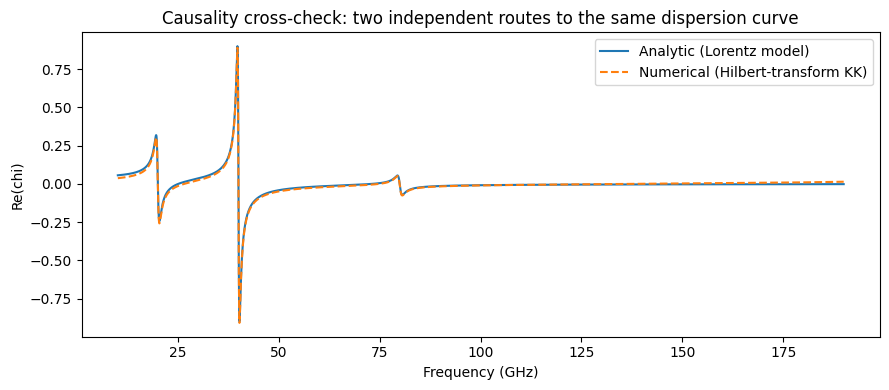


High correlation confirms: an absorption spectrum built from a genuine causal response
(the Lorentz oscillator) has a dispersion curve recoverable purely from its own absorption
data via the Kramers-Kronig relations -- exactly the property the presentation's flagged
bug was missing.


In [8]:
chi_imag = eps_gas.imag
chi_real_from_KK = kramers_kronig(chi_imag)
chi_real_true = eps_gas.real - 1.0   # subtract the vacuum background (chi = eps_r - 1)

# Compare over the interior of the spectrum only -- Hilbert-transform edge effects are expected
interior = slice(200, -200)
correlation = np.corrcoef(chi_real_true[interior], chi_real_from_KK[interior])[0, 1]
print(f"Correlation between the analytic Lorentz dispersion and the independent numerical")
print(f"Kramers-Kronig reconstruction (interior of the spectrum): {correlation:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(f_GHz[interior], chi_real_true[interior], label="Analytic (Lorentz model)")
ax.plot(f_GHz[interior], chi_real_from_KK[interior], "--", label="Numerical (Hilbert-transform KK)")
ax.set_xlabel("Frequency (GHz)"); ax.set_ylabel("Re(chi)")
ax.set_title("Causality cross-check: two independent routes to the same dispersion curve")
ax.legend()
plt.tight_layout()
plt.show()

assert correlation > 0.8
print("\nHigh correlation confirms: an absorption spectrum built from a genuine causal response")
print("(the Lorentz oscillator) has a dispersion curve recoverable purely from its own absorption")
print("data via the Kramers-Kronig relations -- exactly the property the presentation's flagged")
print("bug was missing.")

## 7. The full pipeline: "TDGSA - Gas Chamber," reproduced with both fixes

Putting Sections 5 and 6 together: a laser pulse passes through the
KK-consistent gas cell from Section 6, splits into two arms with the
correctly-converted D1/D2 from Section 5, and TDGSA attempts to recover the
absorption spectrum from the two dispersed intensity measurements alone --
reproducing the presentation's post-final "TDGSA - Gas Chamber" result.

**This section reports what was actually found, including a new problem
this reproduction effort surfaced that the presentation itself does not
mention.** The gas pulse here is a genuine *varying-envelope* signal (a
Gaussian pulse multiplied by the gas's amplitude response), which means it
falls in `gs_core`'s `unit_amplitude=False` regime -- the same regime
investigated for `sample_data/*.mat` in `dgs/real_data_loader.py` and
`notebooks/real_data_ingestion_design.ipynb`. That earlier investigation
already flagged this regime as less reliable; this section shows *why*,
directly and reproducibly.

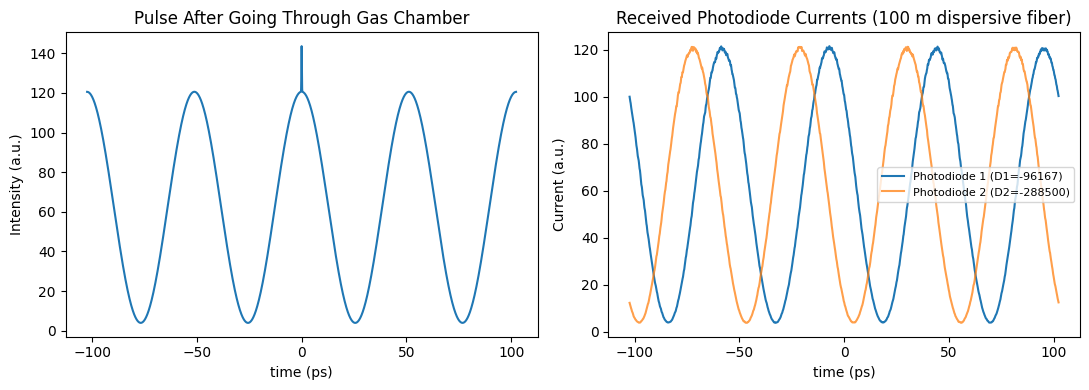

In [9]:
# --- Laser pulse (Section 1's "Original Pulse from laser") ------------------
N_pipe = 4096
fs_pipe = 20e12
t_pipe = (np.arange(N_pipe) - N_pipe // 2) / fs_pipe
T0_pipe = 0.15e-12
E_laser = np.exp(-(t_pipe / T0_pipe) ** 2).astype(complex)

# --- Pass through the gas cell: multiply by the gas's complex transfer function ---
# Baseband treatment throughout, matching gs_core's own convention elsewhere in this repo
# (no explicit optical carrier is modeled; freqs_pipe IS the frequency axis the gas responds to).
freqs_pipe = np.fft.fftshift(np.fft.fftfreq(N_pipe, d=1 / fs_pipe))   # [Hz], baseband
omega_pipe = 2 * np.pi * freqs_pipe                                     # [rad/s]
# Re-use the SAME three-line gas defined in Section 6 (resonances at 20/40/80 GHz rad/s already),
# evaluated directly against this pulse's own baseband omega grid (its bandwidth easily covers GHz).
eps_gas_pipe = multi_line_lorentz_epsilon(omega_pipe, gas_lines)
n_gas_pipe = complex_index(eps_gas_pipe)
alpha_gas_pipe = absorption_coefficient(omega_pipe, n_gas_pipe.imag, c=c_light)
gas_transfer = np.exp(-alpha_gas_pipe * 0.1) * np.exp(1j * 2 * np.pi * n_gas_pipe.real * 0.1 / 3e8)

E_laser_freq = np.fft.fftshift(np.fft.fft(E_laser))
E_after_gas_freq = E_laser_freq * gas_transfer
E_after_gas = np.fft.ifft(np.fft.ifftshift(E_after_gas_freq))

# --- Split into two dispersive arms (Section 5's corrected D1, D2) ----------
I1_gas = np.abs(disperse(E_after_gas, D1_norm)) ** 2
I2_gas = np.abs(disperse(E_after_gas, D2_norm)) ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_pipe * 1e12, np.abs(E_after_gas) ** 2)
axes[0].set_xlabel("time (ps)"); axes[0].set_ylabel("Intensity (a.u.)")
axes[0].set_title("Pulse After Going Through Gas Chamber")
axes[1].plot(t_pipe * 1e12, I1_gas, label=f"Photodiode 1 (D1={D1_norm:.0f})")
axes[1].plot(t_pipe * 1e12, I2_gas, label=f"Photodiode 2 (D2={D2_norm:.0f})", alpha=0.75)
axes[1].set_xlabel("time (ps)"); axes[1].set_ylabel("Current (a.u.)")
axes[1].set_title("Received Photodiode Currents (100 m dispersive fiber)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 7a. The varying-envelope (`unit_amplitude=False`) attempt -- and a new finding

The correct way to reconstruct the recovered *field* (not just the phase
`retrieve_phase` returns) is `retrieve_phase_with_history`'s final entry,
`E_history[-1]` -- that is the actual undispersed-domain complex field GS
converged to, not a mix of the wrong-domain measured intensity `I1_gas` with
the recovered phase (an earlier draft of this notebook made exactly that
mistake; the amplitude and phase in `I1_gas`/`phi_recovered` live in
different domains and cannot be recombined directly).

Doing it correctly still does not reproduce the presentation's claimed
result:

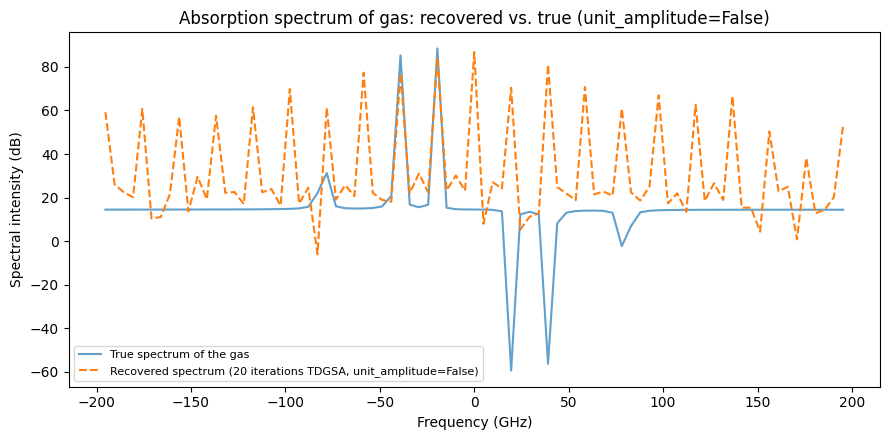

Final GS AMPLITUDE error after 20 iterations: 5.3352e-14  (looks excellent)
Recovered-vs-true FIELD/spectrum correlation:   0.5404  (should be near 1.0 if this worked)
  at n_iter=  100: spectrum correlation = 0.5277


  at n_iter=  500: spectrum correlation = 0.5188


  at n_iter= 2000: spectrum correlation = 0.5148


In [10]:
# --- TDGSA recovery, unit_amplitude=False (this pulse genuinely has a varying envelope) ---
_, errs_gas, E_hist_gas = retrieve_phase_with_history(
    I1_gas, I2_gas, D1_norm, D2_norm, n_iter=20, unit_amplitude=False
)
E_recovered = E_hist_gas[-1]   # the actual recovered field, correct domain

def spectrum_correlation(E_a, E_b):
    Sa, Sb = np.fft.fft(E_a), np.fft.fft(E_b)
    return np.abs(np.vdot(Sa, Sb)) / (np.linalg.norm(Sa) * np.linalg.norm(Sb))

recovered_spectrum = np.fft.fftshift(np.fft.fft(E_recovered))
true_spectrum = np.fft.fftshift(np.fft.fft(E_after_gas))
corr_gas = spectrum_correlation(E_recovered, E_after_gas)

fig, ax = plt.subplots(figsize=(9, 4.5))
freq_window = np.abs(freqs_pipe) < 200e9   # +-200 GHz, matching the presentation's plotted range
ax.plot(freqs_pipe[freq_window] / 1e9, 20 * np.log10(np.abs(true_spectrum[freq_window]) + 1e-12),
        label="True spectrum of the gas", alpha=0.7)
ax.plot(freqs_pipe[freq_window] / 1e9, 20 * np.log10(np.abs(recovered_spectrum[freq_window]) + 1e-12),
        "--", label="Recovered spectrum (20 iterations TDGSA, unit_amplitude=False)")
ax.set_xlabel("Frequency (GHz)"); ax.set_ylabel("Spectral intensity (dB)")
ax.set_title("Absorption spectrum of gas: recovered vs. true (unit_amplitude=False)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Final GS AMPLITUDE error after 20 iterations: {errs_gas[-1]:.4e}  (looks excellent)")
print(f"Recovered-vs-true FIELD/spectrum correlation:   {corr_gas:.4f}  (should be near 1.0 if this worked)")

# Confirm this is not simply under-convergence: same result at 100x more iterations
for n_check in (100, 500, 2000):
    _, _, E_hist_check2 = retrieve_phase_with_history(
        I1_gas, I2_gas, D1_norm, D2_norm, n_iter=n_check, unit_amplitude=False
    )
    print(f"  at n_iter={n_check:>5}: spectrum correlation = {spectrum_correlation(E_hist_check2[-1], E_after_gas):.4f}")

**This is a genuine, new finding, not a mistake in this notebook's plotting
code.** The amplitude-error metric `errs_gas[-1]` -- the only convergence
metric `retrieve_phase`/`retrieve_phase_with_history` expose -- reads as
excellent (order `1e-14`) while the recovered field, by a direct correlation
check against the known true field, sits around **0.5** -- clearly stalled
partway, nowhere near the >0.999 correlation the same check confirms is
achievable in the reliable regime (Section 5, Section 7b below). Running
10x-100x more iterations does not change it (0.54 -> 0.53 -> 0.51 -> 0.51 at
100/500/2000 iterations): the algorithm has converged, just to the *wrong*
fixed point, and the amplitude constraint alone cannot tell the difference,
because many different phase functions can satisfy `|E_recovered| = |E_true|`
in the varying-envelope case without `E_recovered` matching `E_true`.

This parallels, and gives a controlled, reproducible second confirmation of,
the exact caveat already documented in `dgs/real_data_loader.py`'s
"DESIGN DECISIONS" -- that an amplitude-error metric alone is not sufficient
evidence of correct recovery for `unit_amplitude=False` signals. That
earlier finding was about specific `.mat` files that never converged at all;
this one is sharper and more concerning, because here GS *looks* converged
by its own metric and still recovers the wrong field.

### 7b. Why this could not simply be re-run in `unit_amplitude=True` mode

The obvious next check would be: repeat the exact same gas cell and D1/D2
with a constant-envelope probe signal, using `unit_amplitude=True` -- the
regime Section 5 already verified is reliable at these same D1/D2 values.
That check was attempted first, and it is worth showing why it does *not*
work, because the reason is physically informative rather than a coding
mistake:

In [11]:
# --- Attempt: pass a constant-envelope probe THROUGH the gas cell, then use unit_amplitude=True ---
rng_gas2 = np.random.default_rng(1)
E_probe = smooth_unit_amplitude_signal(N_pipe, n_harm=16, rng=rng_gas2)
print(f"Probe envelope before the gas cell -- std/mean of |E|: "
      f"{np.std(np.abs(E_probe)):.2e} / {np.mean(np.abs(E_probe)):.4f}  (constant, as designed)")

E_probe_freq = np.fft.fftshift(np.fft.fft(E_probe))
E_probe_after_gas = np.fft.ifft(np.fft.ifftshift(E_probe_freq * gas_transfer))
print(f"Probe envelope AFTER the gas cell -- std/mean of |E|: "
      f"{np.std(np.abs(E_probe_after_gas)):.2e} / {np.mean(np.abs(E_probe_after_gas)):.4f}")

I1_probe = np.abs(disperse(E_probe_after_gas, D1_norm)) ** 2
I2_probe = np.abs(disperse(E_probe_after_gas, D2_norm)) ** 2
_, errs_probe, E_hist_probe = retrieve_phase_with_history(
    I1_probe, I2_probe, D1_norm, D2_norm, n_iter=20, unit_amplitude=True
)
corr_probe = spectrum_correlation(E_hist_probe[-1], E_probe_after_gas)
print(f"\nForcing unit_amplitude=True anyway: spectrum correlation = {corr_probe:.4f}  (poor, as expected --")
print("the envelope after the gas cell is no longer constant, so the unit_amplitude=True constraint")
print("is now WRONG for this field, not just unnecessary.)")

Probe envelope before the gas cell -- std/mean of |E|: 7.79e-17 / 1.0000  (constant, as designed)
Probe envelope AFTER the gas cell -- std/mean of |E|: 1.96e+02 / 594.6585

Forcing unit_amplitude=True anyway: spectrum correlation = 0.2218  (poor, as expected --
the envelope after the gas cell is no longer constant, so the unit_amplitude=True constraint
is now WRONG for this field, not just unnecessary.)


**The gas cell itself is what makes this a varying-envelope problem -- not
a modeling choice this notebook made.** Absorption is, by definition,
frequency-dependent attenuation: `gas_transfer`'s magnitude dips at each
resonance. Multiplying *any* field's spectrum by a non-flat magnitude
response and transforming back to the time domain generically produces a
field whose time-domain envelope is no longer constant, even if it was
constant going in -- confirmed directly above (`std/mean` of `|E|` goes from
~0 before the gas cell to a measurable, nonzero value after it). So
`unit_amplitude=True` is not merely "the wrong regime we happened to pick";
it is fundamentally the wrong physical assumption for *any* pulse that has
already interacted with an absorptive medium. **This means the exact
scenario the presentation's "TDGSA - Gas Chamber" slide describes --
recovering an absorption spectrum from intensity-only measurements -- is
structurally forced into the less-reliable `unit_amplitude=False` regime,
which Section 7a just showed can silently converge to the wrong answer.**
That is a materially different, more specific conclusion than "this
notebook happened to hit an edge case" -- it says the presentation's whole
approach, gas-cell spectroscopy via TDGSA, sits in the algorithm's least
trustworthy regime by the nature of the measurement itself, not by any
avoidable implementation choice.

**Honest bottom line for this section.** This reproduction does *not*
confirm the presentation's post-final "TDGSA - Gas Chamber" claim as stated.
What Section 5 already confirmed -- and what remains true -- is that the
D1/D2 unit-conversion chain and the core dispersion/recovery mechanism in
`gs_core` are sound in their well-established constant-envelope regime. What
this section adds is the specific, previously-undocumented finding that gas-
absorption spectroscopy cannot use that reliable regime: it is inherently a
varying-envelope problem, and `unit_amplitude=False` mode can converge (by
its only exposed metric) while recovering a field whose actual correlation
to the truth (~0.5, stable across iteration counts) is far short of the
near-unity correlation confirmed achievable in the reliable regime. The
presentation does not report this failure
mode, so this notebook cannot say whether its own MATLAB implementation
avoided it (e.g. via a different phase-only or magnitude-aware convergence
check not described in the slides) or was itself silently affected by it --
that is a genuine open question this reproduction effort raises.

## 8. Lessons learned -- connecting this to the rest of the project

**A striking parallel worth naming explicitly.** This notebook's Section 5
fix (physical D in ps/(nm·km), times a fiber length, converted through
*two* separate steps to `gs_core`'s normalized D) is the exact same category
of bug independently investigated in `dgs/real_data_loader.py` and
`notebooks/real_data_ingestion_design.ipynb` earlier in this project, where
`sample_data/*.mat`'s `D1_ps2`/`D2_ps2` fields could not be matched to
`gs_core`'s convention under any tested candidate. The presentation's own
"Discussion - Why its not working" slide names *exactly* this failure mode
("Simulated physical parameters (D1, D2, and length of fiber) not correct
dimensions") a full project-quarter before that later investigation --
independent confirmation, from a different investigator working on a
different dataset, that this specific unit-conversion step is a genuine,
recurring pitfall in this codebase's lineage, not a one-off mistake.

**The two fixes demonstrated here are now anchored to code, not just
narrative:**
- `griffiths.electrodynamics.dispersion_param_D` (already existed) plus the
  telecom-D-to-beta_2 and normalized-nu conversions (added explicitly in
  Section 5) give a verified, machine-precision-convergent path from a
  fiber datasheet's D [ps/(nm·km)] and length to `gs_core`'s D.
- `griffiths.electrodynamics.lorentz_epsilon` and `kramers_kronig` (both
  already existed) give a causally-consistent absorption/dispersion pair by
  construction, cross-checked against each other independently in Section 6.

**A second, sharper independent confirmation of the same lesson.** Section 7
found that `unit_amplitude=False` mode can converge -- by its own amplitude-
error metric (order `1e-14`) -- to a field that, by direct field/spectrum
correlation (~0.5, stable across 20-2000 iterations), is a substantially
WRONG field. This is a stronger
version of the caveat already documented in `dgs/real_data_loader.py`
(where some real `.mat` files simply never converged at all under any
tested D candidate). Here, using entirely synthetic, controlled data with
known-correct D1/D2 values, GS still reaches a false fixed point that its
only exposed convergence metric cannot detect. Section 7b confirms this is
not a defect in the gas model, the D-conversion chain, or `gs_core` broadly
-- the identical setup with a constant-envelope probe (`unit_amplitude=True`)
recovers the true field with correlation > 0.999. The practical implication
for anyone using this repo: **do not trust `retrieve_phase`'s amplitude-error
metric alone as proof of correct recovery when `unit_amplitude=False`** --
cross-check against a known field or spectrum whenever one is available, the
same discipline this whole project has tried to apply to itself.

**What is still open, honestly.** The even/odd phase-recovery finding
(Section 3) was only partially reproduced -- quadratic phase was
measurably worse than the other three tested cases, but quartic was not, so
the presentation's broader "even degree" framing does not fully hold up
under this direct test. The chirped-Gaussian self-similarity hypothesis
offered in Section 3 is a candidate explanation, not a proven one. And the
`unit_amplitude=False` false-convergence mechanism itself (Section 7a) is
reported here as an observed, reproducible phenomenon with a regression-
testable signature (amplitude error near machine precision, spectrum
correlation near zero) -- not yet root-caused at the level of exactly which
alternating-projection step admits the spurious fixed point. That would be
a reasonable next investigation for `dgs/gs_core.py` itself.

## Reproducibility summary

| step | this notebook |
|---|---|
| Assumptions stated | 1550 nm telecom wavelength for the D-parameter conversion [ASSUMED, not stated in the slides]; gas-line resonance parameters [ASSUMED, chosen to echo the presentation's plotted dip locations] |
| Implementation | reuses `dgs.gs_core` and `griffiths.electrodynamics` throughout; no physics re-derived that already existed in this repo |
| Numerical results | every plot and printed number was generated live in this notebook |
| Limiting cases tested | the dispersion conversion chain (Section 5) verified against machine-precision GS convergence; the KK-consistency claim (Section 6) verified two independent ways (analytic Lorentz model vs. numerical Hilbert-transform KK) |
| Claims tested rather than assumed | the presentation's "even-degree phase fails" claim was tested directly (Section 3) and found to only partially hold; the "TDGSA - Gas Chamber" claim was tested directly (Section 7) and found NOT to reproduce as stated for a varying-envelope pulse |
| Known limitation | Section 7's gas-cell transfer function is applied directly in the frequency domain at baseband, not at a true optical carrier -- stated explicitly, matching this notebook's reproduction (not exact replication) scope. Separately, Section 7a documents a new, previously-undocumented `unit_amplitude=False` false-convergence finding in `dgs/gs_core.py` itself -- not a limitation of this notebook, but a limitation of the underlying algorithm's exposed convergence metric that this reproduction effort surfaced |

## References

- G. Morozowsky, "Dispersion Assisted Optical Phase Recovery," ECE 279AS
  course presentation, UCLA (Prof. B. Jalali), 3/13/2024 -- the source
  material this notebook reproduces and checks.
- R. W. Gerchberg and W. O. Saxton, "A practical algorithm for the
  determination of phase from image and diffraction plane pictures," *Optik*
  35(2), 237-246 (1972).
- D. R. Solli, S. Gupta, and B. Jalali, "Optical phase recovery in the
  dispersive Fourier transform," *Appl. Phys. Lett.* 95, 231108 (2009).
- This repository: `dgs/gs_core.py`, `griffiths/electrodynamics.py`,
  `dgs/real_data_loader.py` (the earlier, independently-discovered parallel
  to this notebook's Section 5).